# Import Required Libraries

In [16]:
import torch 
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision.datasets import MNIST

from torch.utils.data import DataLoader
import torchvision.transforms as transforms


import matplotlib.pyplot as plt
import pandas as pd


# Preprocessing with Normalization

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
])

In [3]:
trainset = MNIST("./cnn", train=True, download=False, transform  = transform)
testset = MNIST("./cnn", train=False, download=False, transform = transform)

In [4]:
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64)

In [5]:
trainset

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./cnn
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=0.5, std=0.5)
           )

# Build CNN architecture For MNIST Dataset

In [6]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv_Layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2)  
        )
        self.FLC_Layers = nn.Sequential(
            nn.Linear(3*3*128, 256),
            nn.ReLU(),
            
            nn.Linear(256, 10)
        )
    def forward(self, x):
        x = self.conv_Layers(x)
        x = x.view(x.size(0), -1) # Fallten 
        x = self.FLC_Layers(x)

        return x

In [7]:
model = CNN()
criterion = nn.CrossEntropyLoss()
optimizers = optim.Adam(model.parameters())

# Model Training

In [8]:
epochs = 10
train_loss = []
test_loss = []
best_val_loss = float("inf")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in trainloader:
        optimizers.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizers.step()
        running_loss += loss.item()

    per_train = running_loss / len(trainloader)

    train_loss.append(per_train)


    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in testloader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    per_val = val_loss / len(testloader)
    test_loss.append(per_val)
        
    print(f"In epoch {epoch + 1} / {epochs}, the training loss is {per_train} and validation loss is {per_val}.")  
    
    if best_val_loss > per_val:
        per_val = best_val_loss
        torch.save(model.state_dict(), "Best Model.pt")

In epoch 1 / 10, the training loss is 0.15949047423689675 and validation loss is 0.035712072120517475.
In epoch 2 / 10, the training loss is 0.042046764700202896 and validation loss is 0.03732347284222339.
In epoch 3 / 10, the training loss is 0.031971672282107164 and validation loss is 0.03169768963087069.
In epoch 4 / 10, the training loss is 0.023011438560029587 and validation loss is 0.024775126974603903.
In epoch 5 / 10, the training loss is 0.018595072390844836 and validation loss is 0.029486929639709964.
In epoch 6 / 10, the training loss is 0.015217983112833532 and validation loss is 0.041266257086657106.
In epoch 7 / 10, the training loss is 0.01417292736881663 and validation loss is 0.022018328359626613.
In epoch 8 / 10, the training loss is 0.010758313148280085 and validation loss is 0.02620634017323171.
In epoch 9 / 10, the training loss is 0.009720329617742864 and validation loss is 0.03361703601269478.
In epoch 10 / 10, the training loss is 0.008313284720483505 and valida

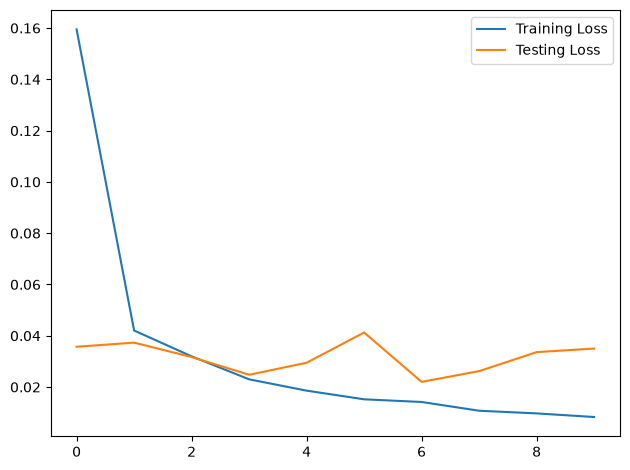

In [22]:
df = pd.DataFrame({
                  "Training Loss": train_loss,
                  "Testing Loss": test_loss 
                  })
                  
plt.plot(df["Training Loss"], label="Training Loss")
plt.plot(df["Testing Loss"], label="Testing Loss")
plt.legend()
plt.tight_layout()

# Model Evaluation And Make Prediction

In [9]:
correct = 0
total = 0
model.eval()
with torch.no_grad():
    
    for images, labels in testloader:
        
        outputs = model(images)
        _,predict = torch.max(outputs, 1)
        correct += (predict == labels).sum().item()
        total += labels.size(0)

        accuracy = correct / total

    print("Accuracy: ", accuracy * 100)
        

Accuracy:  99.22


In [10]:
model.load_state_dict(torch.load("Best Model.pt"))

<All keys matched successfully>

# Print prediction and labels

In [11]:
predict

tensor([1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6])

In [12]:
labels

tensor([1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6])

# Visualization of Prediction

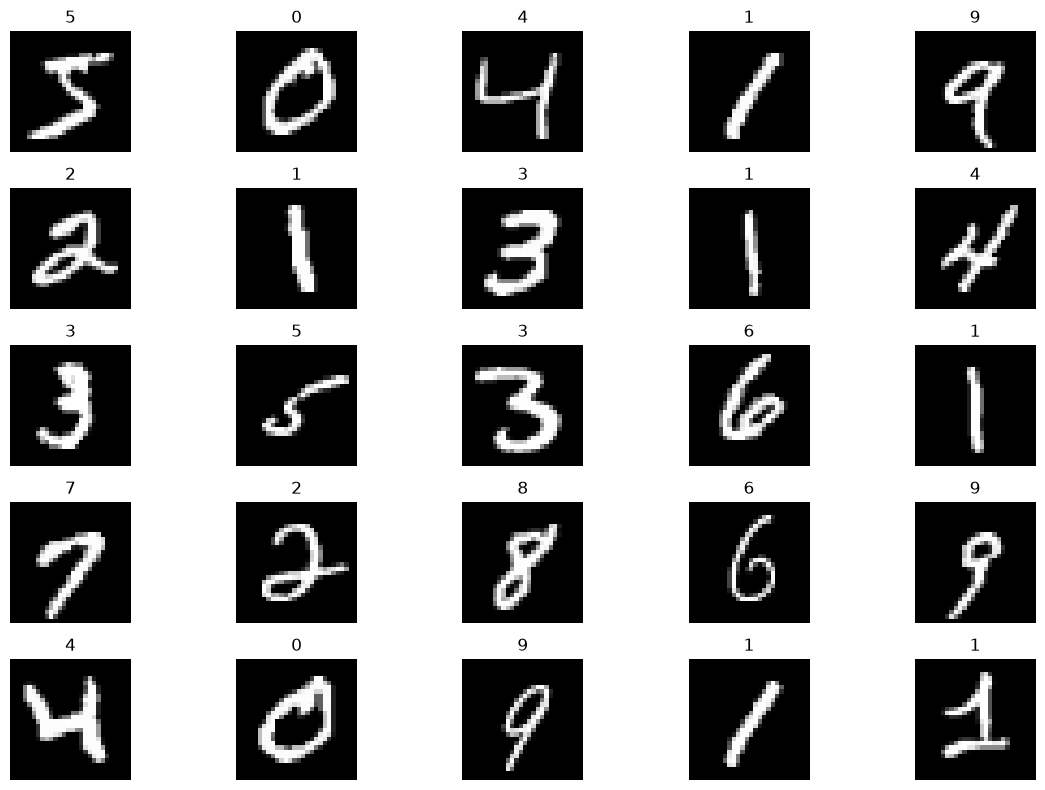

In [13]:

# Load the dataset
dataset = (trainset)

fig, axes = plt.subplots(5, 5, figsize=(12, 8))

for i, ax in enumerate(axes.flat):
    image, label = dataset[i]

   
    if len(image.shape) == 3:
        image = image.squeeze()

    ax.imshow(image, cmap="gray")
    ax.set_title(f"{label}")
    ax.axis("off")

plt.tight_layout()
plt.show()